# Lab 2: Multiclass Classification on the Iris Dataset Using K-Nearest Neighbors (KNN)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score, f1_score)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [2]:
iris = load_iris()

In [14]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species']= pd.Categorical.from_codes(iris.target, iris.target_names)
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [24]:
print("Iris Dataset Keys:", iris.keys())
print("\nIris Dataset Description:")
print(iris.DESCR)
print("\nDataFrame Info:")
df.info()
print("\nDataFrame Description:")
df.describe()

Iris Dataset Keys: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

Iris Dataset Description:
.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
X = iris.data
y = iris.target

In [5]:
# Splitting the dataset into training:testing split = 0.7:0.3
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42

)

In [19]:
# Default Metric: Euclidean distance for K-Nearest Neighbor Classification
knn_default = KNeighborsClassifier(n_neighbors=5, metric='euclidean', weights='distance')
knn_default.fit(X_train, y_train)
y_pred_default = knn_default.predict(X_test)

In [20]:
# Model Evaluation
# Calculating metrics
accuracy_def = accuracy_score(y_test, y_pred_default)
precision_def = precision_score(y_test, y_pred_default, average='macro')
recall_def = recall_score(y_test, y_pred_default, average='macro')
f1_def = f1_score(y_test, y_pred_default, average='macro')
cm_def = confusion_matrix(y_test, y_pred_default)

In [21]:
# Output Results
print("Default KNN Model Evaluation")
print(f"Accuracy:  {accuracy_def:.4f}")
print(f"Precision: {precision_def:.4f} (Macro)")
print(f"Recall:    {recall_def:.4f} (Macro)")
print(f"F1-Score:  {f1_def:.4f} (Macro)")
print("\nClassification Report:\n", classification_report(y_test, y_pred_default, target_names=iris.target_names))

Default KNN Model Evaluation
Accuracy:  1.0000
Precision: 1.0000 (Macro)
Recall:    1.0000 (Macro)
F1-Score:  1.0000 (Macro)

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



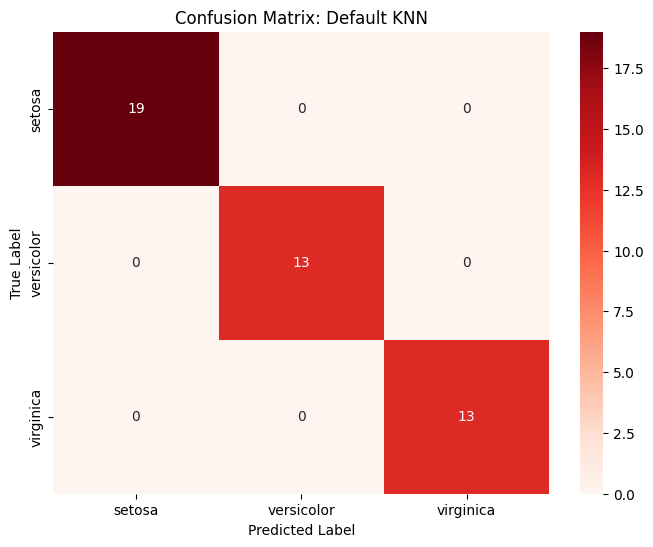

In [9]:
# Visualizing the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_def, annot=True, fmt='d', cmap='Reds',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix: Default KNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [10]:
# Now, we tune the hyperparameters of the model, changing metric from euclidean to manhattan
knn_tuned = KNeighborsClassifier(n_neighbors=10, metric='manhattan', weights='uniform')
knn_tuned.fit(X_train, y_train)
y_pred_tuned = knn_tuned.predict(X_test)

In [11]:
# Model Evaluation
# Calculating metrics
accuracy = accuracy_score(y_test, y_pred_tuned)
precision = precision_score(y_test, y_pred_tuned, average='macro')
recall = recall_score(y_test, y_pred_tuned, average='macro')
f1 = f1_score(y_test, y_pred_tuned, average='macro')
cm = confusion_matrix(y_test, y_pred_tuned)

In [16]:
# Output Results
print("Tuned KNN Model Evaluation")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f} (Macro)")
print(f"Recall:    {recall:.4f} (Macro)")
print(f"F1-Score:  {f1:.4f} (Macro)")
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned, target_names=iris.target_names))

Tuned KNN Model Evaluation
Accuracy:  0.9778
Precision: 0.9762 (Macro)
Recall:    0.9744 (Macro)
F1-Score:  0.9743 (Macro)

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.93      1.00      0.96        13
   virginica       1.00      0.92      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



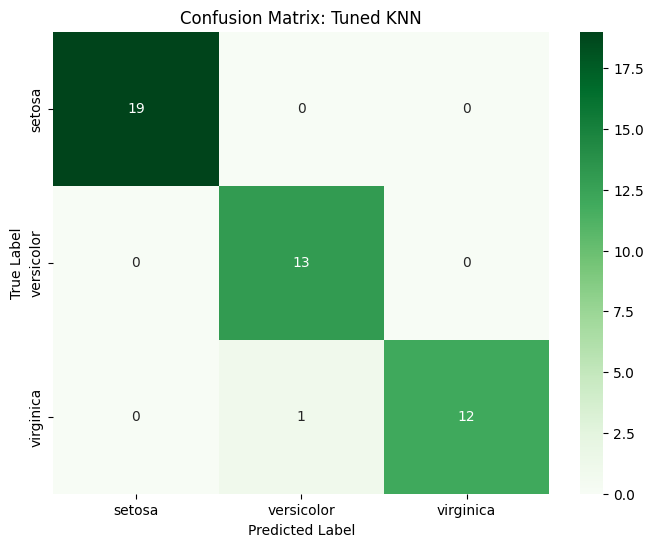

In [22]:
# Visualizing the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix: Tuned KNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()